In [5]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 8.4 MB/s  0:00:00m 10.1 MB/s eta 0:00:01


In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBClassifier

In [10]:
df = pd.read_csv('/Users/milanmanoj/Documents/My Projects/Fintech Customer Risk & Behaviour Intelligence/BankChurners.csv')

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [11]:
df.shape

(10127, 23)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

### Problem Statement

#### The bank wants to:
##### Identify customers likely to churn,
##### Understand customer behaviour patterns,
##### Segment customers based on profitability and engagement,
##### Predict future customer value,
##### Design targeted retention strategies.

In [15]:
drop_cols = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

df.drop(columns=drop_cols, inplace=True)

In [16]:
df.isnull().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

# Exploratory Data Analysis

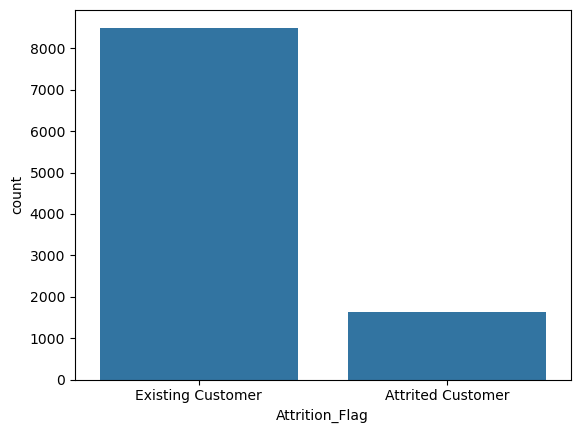

In [17]:
#Churn Distribution

sns.countplot(x='Attrition_Flag', data=df)
plt.show()

### Business Interpretation
##### Majority customers remain active.
##### Churn class imbalance exists.
##### Special attention needed during model evaluation.

# Numerical Feature Distribution

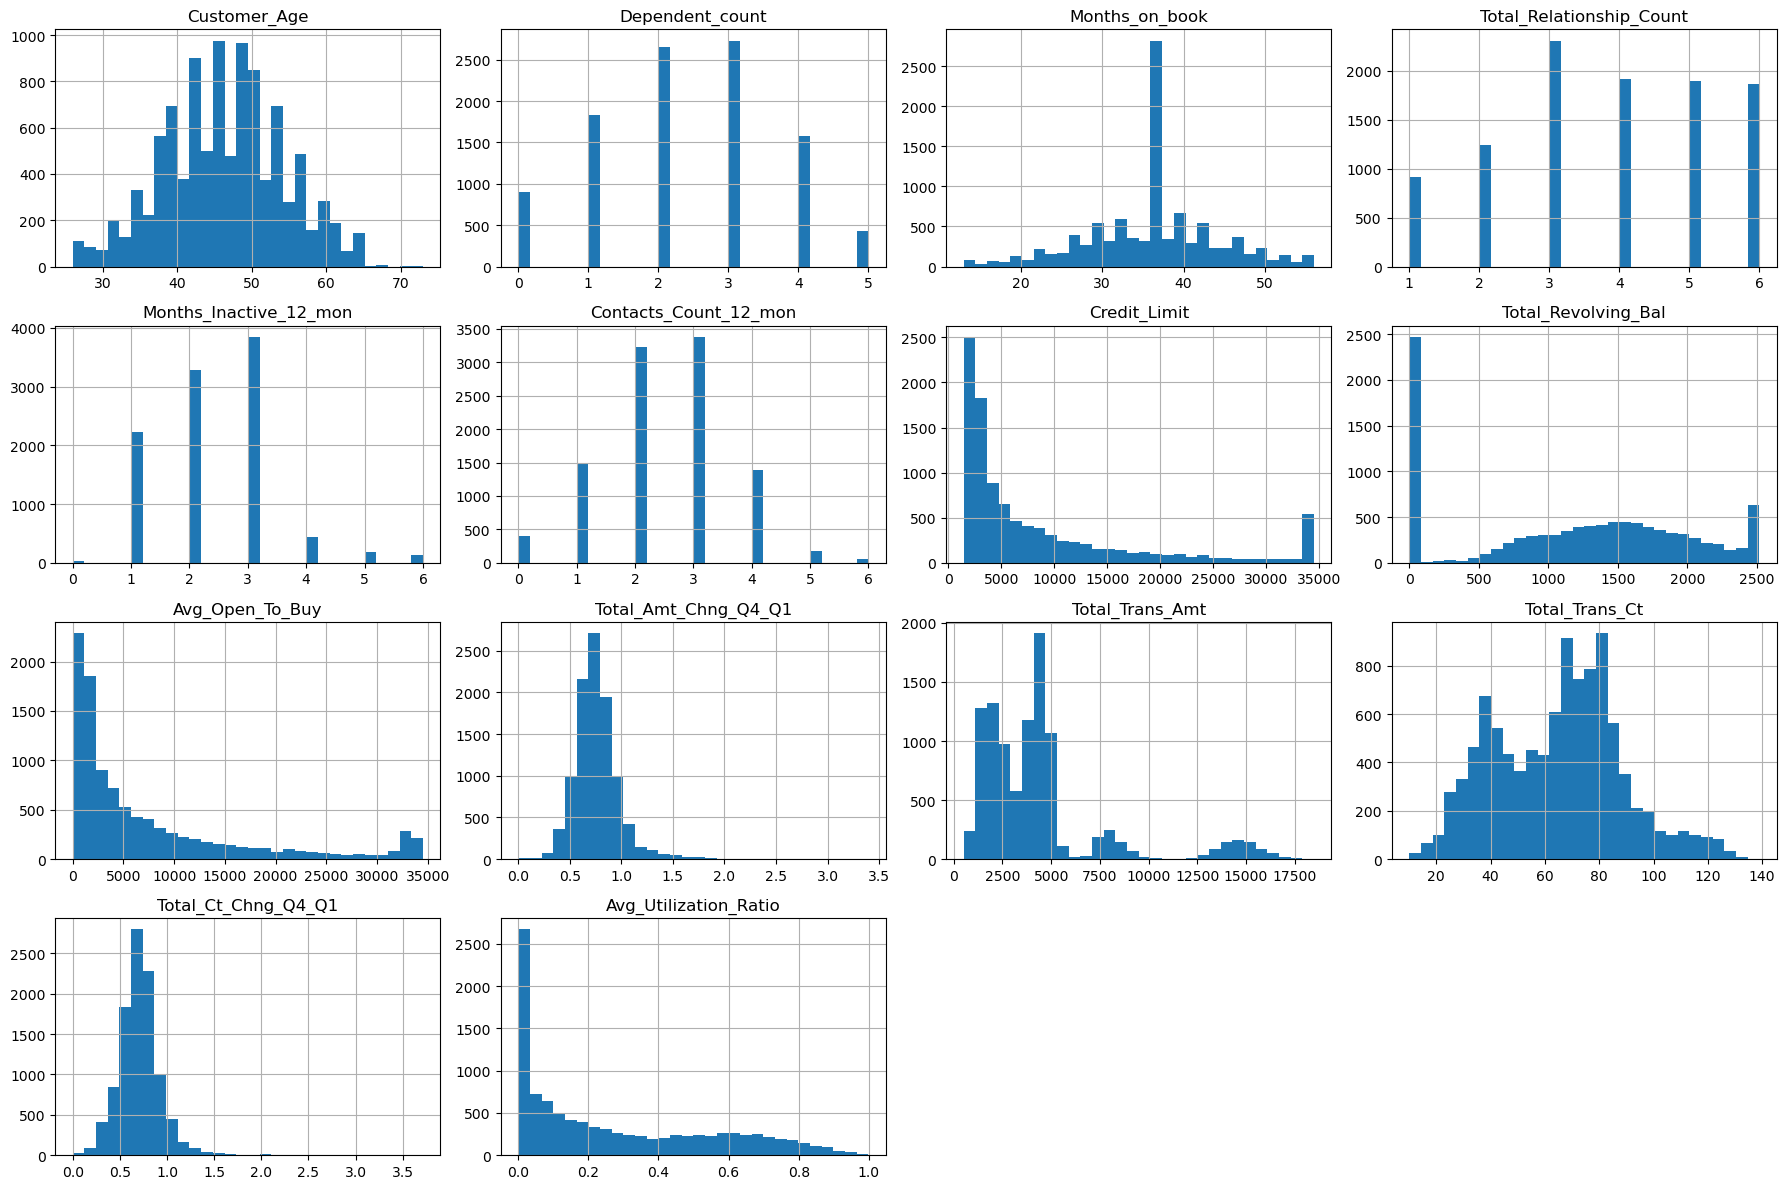

In [18]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

# Correlation Matrix

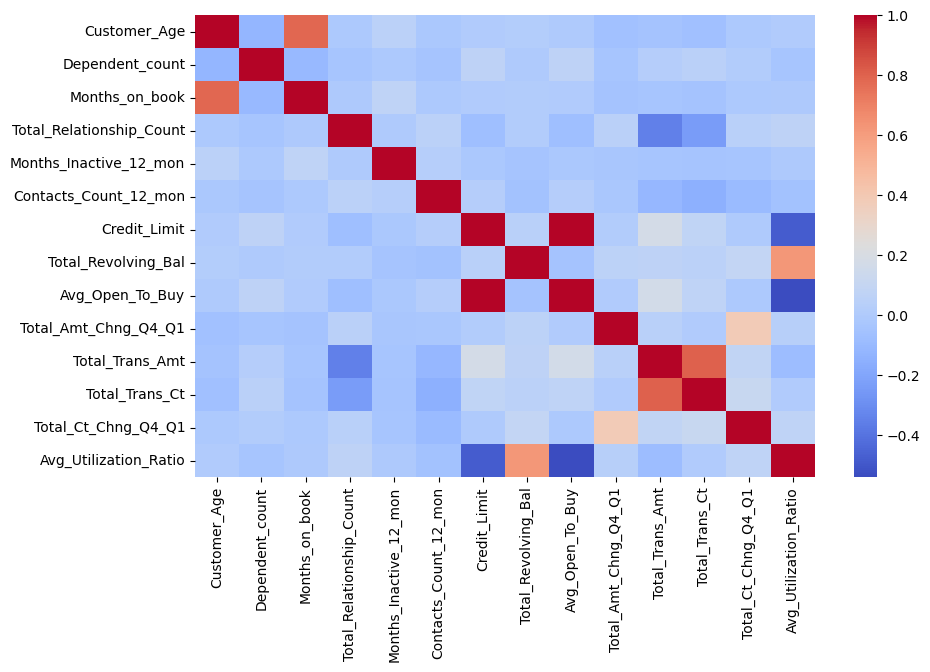

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[num_cols].corr(),
    cmap='coolwarm'
)

plt.show()

### Business Interpretation

#### Key drivers generally include:

##### Total Transaction Amount
##### Total Transaction Count
##### Months Inactive
##### Contacts Count
##### Utilization Ratio

# Outlier Analysis

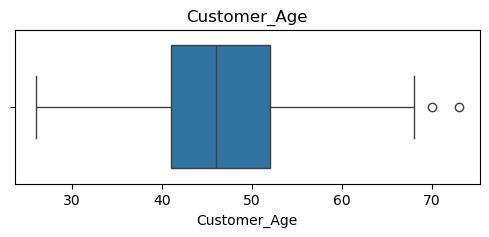

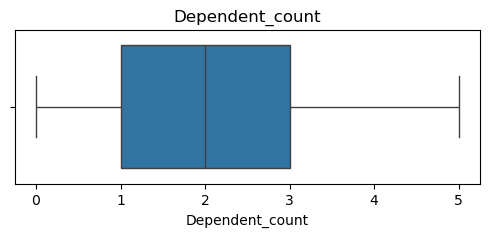

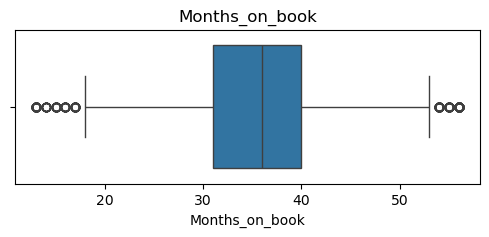

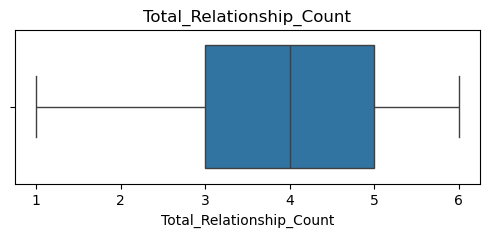

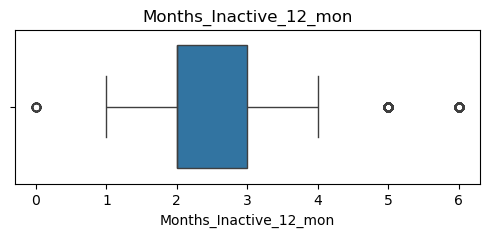

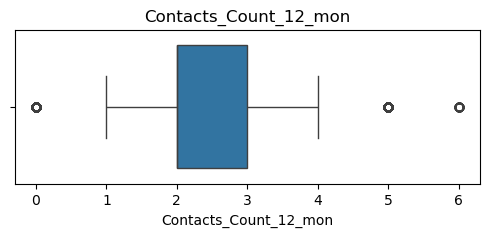

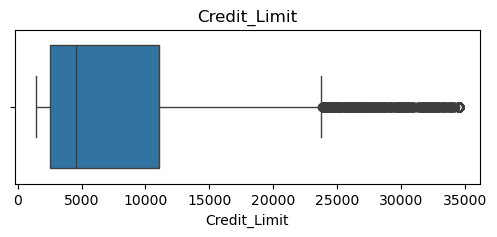

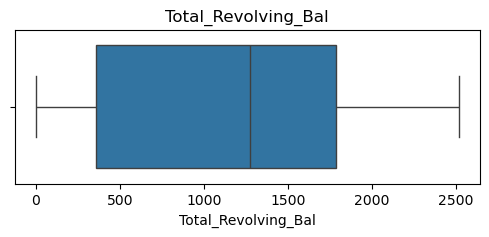

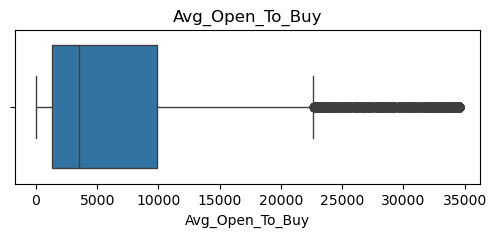

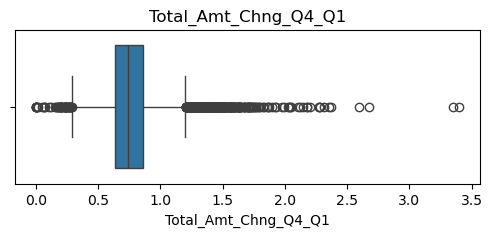

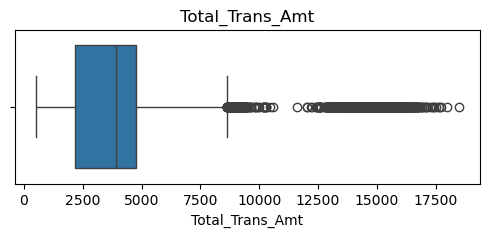

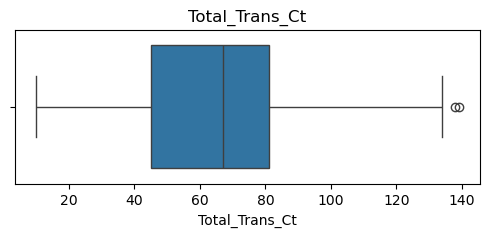

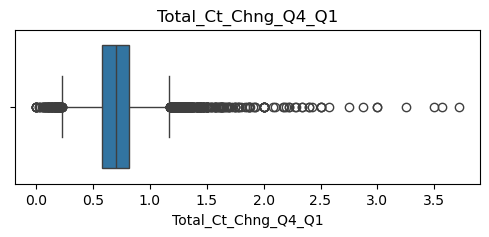

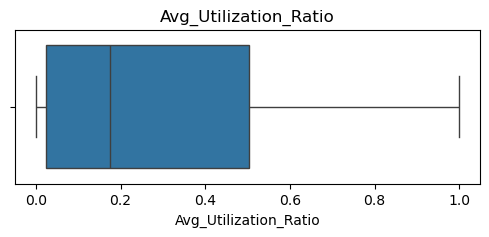

In [22]:
for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

### Business Interpretation
##### Several financial variables show natural skewness.
##### Outliers may represent premium customers rather than errors.
##### Retain outliers for business realism.

# Feature Encoding

In [23]:
df_model = df.copy()

le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Feature Scaling

In [24]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df_model.drop("Attrition_Flag", axis=1)
)

# Customer Segmentation

## K-Means Clustering

### Elbow Method

In [25]:
inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(scaled_data)

    inertia.append(km.inertia_)

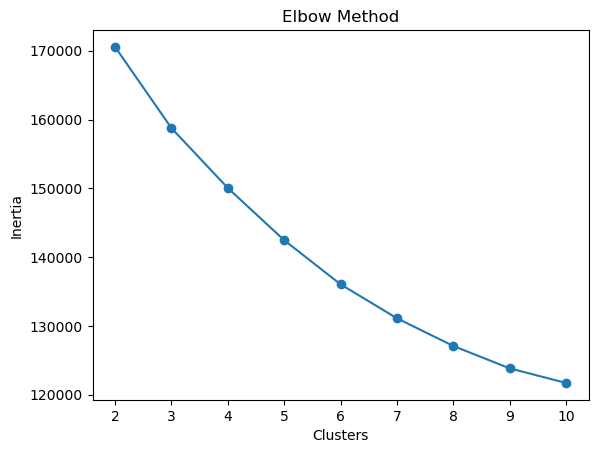

In [26]:
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Silhouette Score

In [28]:
for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(k, score)

2 0.17437045932133932
3 0.08703874746123674
4 0.09575015715711496
5 0.09887374046264631
6 0.09772103212717607
7 0.09539404020792704
8 0.09519704035165058
9 0.09094645964257951
10 0.08337811219612631


### Final Clustering

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df_model["Cluster"] = kmeans.fit_predict(
    scaled_data
)

### Cluster Profiling

In [30]:
cluster_profile = df.groupby(
    df_model["Cluster"]
).mean(numeric_only=True)

cluster_profile

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Cluster,,,,,,,,,,,,,,
0,46.295229,2.312376,35.731362,4.079771,2.309394,2.345676,3574.162276,1680.878728,1893.283549,0.786998,3561.873757,63.181163,0.758239,0.555251
1,46.575853,2.317323,36.312073,3.977690,2.423097,2.634121,6772.588215,543.337008,6229.251207,0.724407,3164.301050,56.975853,0.658675,0.078309
2,46.257485,2.546407,35.827844,3.750749,2.287425,2.478293,27512.522455,1220.958084,26291.564371,0.767022,4592.178144,64.574102,0.714644,0.048928
3,45.555904,2.323929,35.369906,2.118077,2.223615,2.172414,10943.652038,1369.538140,9574.113898,0.777750,12618.667712,103.692790,0.728534,0.194139


### Business Interpretation
#### Cluster 0 – Loyal High Value
##### High transaction volume
##### High credit limits
##### Low inactivity
#### Cluster 1 – Churn Risk
##### Low transaction frequency
##### High inactivity
##### Lower engagement
#### Cluster 2 – Premium Customers
##### Very high credit limits
##### Large spending volume
#### Cluster 3 – Low Value Segment
##### Low balances
##### Lower profitability

## Churn Prediction

### Train-Test Split

In [31]:
X = df_model.drop(
    ["Attrition_Flag","Cluster"],
    axis=1
)

y = df_model["Attrition_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Logistic Regression

In [32]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

prob_lr = lr.predict_proba(X_test)[:,1]

In [33]:
roc_lr = roc_auc_score(y_test, prob_lr)

print(roc_lr)

0.9078822412155745


### Business Interpretation
##### Baseline churn model.
##### Provides explainable probability scores.

### Random Forest

In [34]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

In [35]:
roc_rf = roc_auc_score(
    y_test,
    prob_rf
)

print(roc_rf)

0.9879645457423236


### Feature Importance

In [36]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
15,Total_Trans_Amt,0.185540
16,Total_Trans_Ct,0.175931
17,Total_Ct_Chng_Q4_Q1,0.114711
12,Total_Revolving_Bal,0.104601
8,Total_Relationship_Count,0.067335
18,Avg_Utilization_Ratio,0.064555
14,Total_Amt_Chng_Q4_Q1,0.061048
0,Customer_Age,0.033522
13,Avg_Open_To_Buy,0.031371
11,Credit_Limit,0.030922


### XGBoost

In [37]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train,y_train)

prob_xgb = xgb.predict_proba(X_test)[:,1]

In [38]:
roc_xgb = roc_auc_score(
    y_test,
    prob_xgb
)

print(roc_xgb)

0.9921078098855877


#### Business Interpretation
##### Usually delivers best predictive performance.
##### Suitable for production churn scoring.

### Confusion Matrix

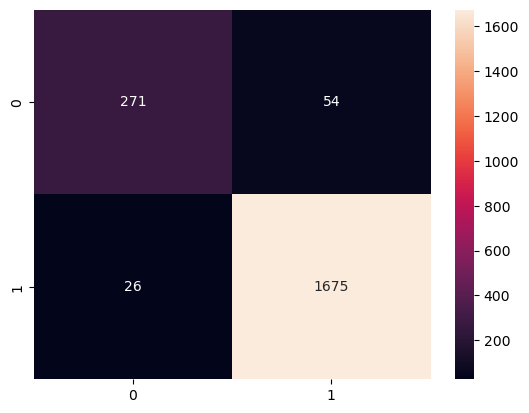

In [39]:
sns.heatmap(
    confusion_matrix(y_test,pred_rf),
    annot=True,
    fmt='d'
)

plt.show()

## Credit Behaviour Prediction

### Credit Limit Prediction

#### Define Target

In [40]:
X_reg = df_model.drop(
    ['Credit_Limit'],
    axis=1
)

y_reg = df_model['Credit_Limit']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

#### Linear Regression

In [42]:
lin = LinearRegression()

lin.fit(X_train,y_train)

pred = lin.predict(X_test)

In [43]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

mae = mean_absolute_error(
    y_test,
    pred
)

r2 = r2_score(
    y_test,
    pred
)

print(rmse, mae, r2)

1.4242737903443407e-11 1.0342696535783504e-11 1.0


#### Ridge Regression

In [47]:
ridge = Ridge(alpha=1)

ridge.fit(X_train,y_train)

pred_ridge = ridge.predict(X_test)

print(pred_ridge)

[ 2990.99999999  2192.00000019  1734.00000026 ...  5593.99999986
  8712.99999986 22053.99999996]


#### Lasso Regression

In [45]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train,y_train)

pred_lasso = lasso.predict(X_test)

In [48]:
print(pred_lasso)

[ 2991.00032472  2192.00038098  1734.00080409 ...  5594.00029657
  8712.99977023 22053.99884444]


### Business Interpretation
#### Helps estimate customer borrowing capacity.
#### Useful for risk-based credit strategies.

## Hypothesis Testing
### Test 1
#### Is churn related to income category?
#### H0
#### Churn is independent of income category.
#### H1
#### Churn depends on income category.

In [49]:
contingency = pd.crosstab(
    df['Income_Category'],
    df['Attrition_Flag']
)

chi2,p,dof,expected = chi2_contingency(
    contingency
)

print(p)

0.025002425704390645


##### If p < 0.05:
##### Reject H0
##### Income category significantly influences churn.

### Test 2
#### Do churned customers spend less?
#### H0
#### Transaction distributions are equal.
#### H1
#### Transaction distributions differ.

In [50]:
churned = df[
    df['Attrition_Flag']=='Attrited Customer'
]['Total_Trans_Amt']

active = df[
    df['Attrition_Flag']=='Existing Customer'
]['Total_Trans_Amt']

stat,p = mannwhitneyu(
    churned,
    active
)

print(p)

2.719009390771485e-112


##### If p < 0.05:

##### Churned customers exhibit significantly different transaction behaviour.

#### Final Business Insights
#### Key Findings
#### Customer Segmentation
##### Identified distinct behavioural groups
##### High-value customers contribute majority revenue
##### High-risk segments show inactivity patterns
#### Churn Analytics
##### Transaction frequency strongly predicts churn
##### Inactive customers show elevated churn risk
##### XGBoost achieved best predictive performance
#### Credit Behaviour
##### Credit limit strongly associated with spending behaviour
##### Customer activity helps estimate future value
#### Statistical Evidence
##### Income segments exhibit different churn tendencies
##### Churned customers spend significantly less
#### Recommendations
#### Retention Strategy
#### Target:
##### High inactivity customers
##### Low transaction customers
#### Actions:
##### Cashback campaigns
##### Personalized offers
##### Loyalty rewards
#### Premium Upsell
#### Target:
##### High spending clusters
#### Actions:
##### Premium cards
##### Higher credit limits
##### Wealth products
#### Risk Monitoring
#### Build early-warning system using:
##### Transaction decline
##### Inactivity increase
##### Utilization changes